In [1]:
# Importa NumPy para operaciones numéricas
import numpy as np

# Importa Pandas para trabajar con tablas y archivos CSV
import pandas as pd

# Importa Matplotlib para crear gráficos
import matplotlib.pyplot as plt

# Importa Seaborn para mejorar el diseño de los gráficos
import seaborn as sns

# Configura el tamaño predeterminado de los gráficos
plt.rcParams["figure.figsize"] = (10, 5)

# Aplica un estilo visual a los gráficos
sns.set_theme(style="whitegrid")

# Muestra un mensaje para comprobar que todo funcionó
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# Importa Path para trabajar con rutas
from pathlib import Path

# Define la ubicación del archivo CSV
ruta_archivo = Path("../data/snp500_history.csv")

# Verifica que el archivo exista
if not ruta_archivo.exists():
    raise FileNotFoundError(f"No se encontró: {ruta_archivo}")

# Lee el CSV y lo convierte en un DataFrame
df = pd.read_csv(ruta_archivo)

# Muestra la ruta utilizada
print("Archivo cargado:", ruta_archivo)

Archivo cargado: ..\data\snp500_history.csv


In [3]:
# Muestra los primeros 5 registros
display(df.head())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1,1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
2,1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
3,1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
4,1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [4]:
# Muestra los primeros 10 registros
display(df.head(10))

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1,1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
2,1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
3,1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
4,1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
5,1928-01-09 00:00:00-05:00,17.500000,17.500000,17.500000,17.500000,0,0.0,0.0
6,1928-01-10 00:00:00-05:00,17.370001,17.370001,17.370001,17.370001,0,0.0,0.0
7,1928-01-11 00:00:00-05:00,17.350000,17.350000,17.350000,17.350000,0,0.0,0.0
8,1928-01-12 00:00:00-05:00,17.469999,17.469999,17.469999,17.469999,0,0.0,0.0
9,1928-01-13 00:00:00-05:00,17.580000,17.580000,17.580000,17.580000,0,0.0,0.0


In [5]:
# Obtiene la cantidad de filas y columnas
cantidad_filas, cantidad_columnas = df.shape

# Muestra la cantidad de filas
print("Cantidad de filas:", cantidad_filas)

# Muestra la cantidad de columnas
print("Cantidad de columnas:", cantidad_columnas)

Cantidad de filas: 23970
Cantidad de columnas: 8


In [6]:
# Recorre todas las columnas del DataFrame
for columna in df.columns:

    # Muestra el nombre de cada columna
    print(columna)

Date
Open
High
Low
Close
Volume
Dividends
Stock Splits


In [7]:
# Muestra columnas, tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          23970 non-null  str    
 1   Open          23970 non-null  float64
 2   High          23970 non-null  float64
 3   Low           23970 non-null  float64
 4   Close         23970 non-null  float64
 5   Volume        23970 non-null  int64  
 6   Dividends     23970 non-null  float64
 7   Stock Splits  23970 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 1.5 MB


In [8]:
# Cuenta los valores nulos de cada columna
valores_nulos = df.isnull().sum()

# Conserva solamente columnas que tengan valores nulos
columnas_con_nulos = valores_nulos[valores_nulos > 0]

# Comprueba si existen columnas con valores nulos
if columnas_con_nulos.empty:

    # Se ejecuta cuando no hay valores nulos
    print("El dataset no contiene valores nulos.")

else:

    # Muestra las columnas que contienen valores nulos
    display(columnas_con_nulos)

El dataset no contiene valores nulos.


In [9]:
# Cuenta las filas completamente repetidas
cantidad_duplicados = df.duplicated().sum()

# Muestra la cantidad encontrada
print("Filas duplicadas:", cantidad_duplicados)

Filas duplicadas: 0


In [10]:
# Guarda el tamaño original del dataset
filas_antes = df.shape[0]

# Elimina filas completamente repetidas
df = df.drop_duplicates()

# Guarda el tamaño después de la limpieza
filas_despues = df.shape[0]

# Calcula cuántas filas fueron eliminadas
filas_eliminadas = filas_antes - filas_despues

# Muestra el resultado
print("Filas eliminadas:", filas_eliminadas)

Filas eliminadas: 0


In [11]:
# Busca columnas cuyo nombre comience con "Unnamed"
columnas_sin_nombre = df.columns.str.contains(
    "^Unnamed",
    case=False,
    regex=True
)

# Conserva solamente las columnas que sí tienen nombre
df = df.loc[:, ~columnas_sin_nombre]

# Muestra las columnas resultantes
print(df.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [12]:
# Genera estadísticas de las columnas numéricas
estadisticas = df.describe()

# Muestra la tabla de estadísticas
display(estadisticas)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,23970.000000,23970.000000,23970.000000,23970.000000,2.397000e+04,23970.0,23970.0
mean,565.155536,588.712980,581.470939,585.323645,8.698602e+08,0.0,0.0
std,941.065938,935.183705,923.945440,929.927708,1.591868e+09,0.0,0.0
min,0.000000,4.400000,4.400000,4.400000,0.000000e+00,0.0,0.0
25%,9.540000,24.440001,24.440001,24.440001,1.440000e+06,0.0,0.0
50%,40.684999,102.180000,100.580002,101.405003,1.917500e+07,0.0,0.0
75%,961.247513,970.832520,951.692520,962.402512,8.148750e+08,0.0,0.0
max,4804.509766,4818.620117,4780.040039,4796.560059,1.145623e+10,0.0,0.0


In [13]:
# Selecciona únicamente columnas numéricas
columnas_numericas = df.select_dtypes(
    include=np.number
).columns

# Convierte los nombres en una lista
lista_numericas = columnas_numericas.tolist()

# Muestra las columnas encontradas
print("Columnas numéricas:", lista_numericas)

Columnas numéricas: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


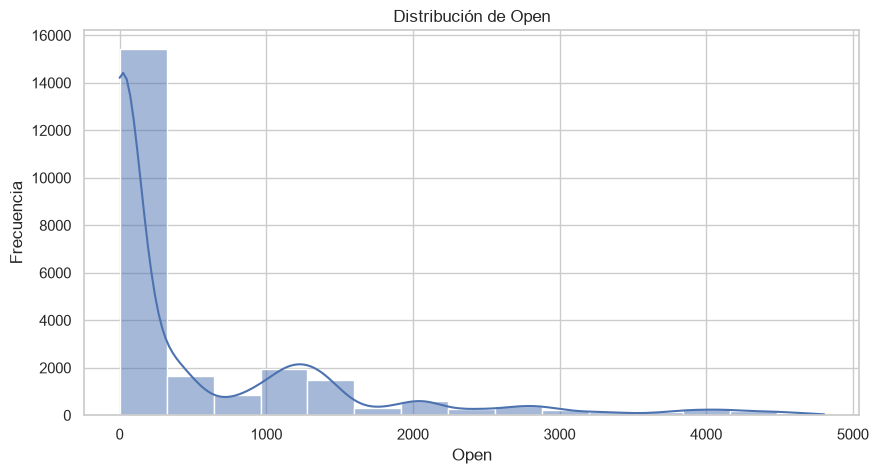

In [14]:
# Comprueba que exista al menos una columna numérica
if len(columnas_numericas) > 0:

    # Selecciona la primera columna numérica
    columna_grafico = columnas_numericas[0]

    # Crea un histograma con 15 intervalos
    sns.histplot(
        data=df,
        x=columna_grafico,
        bins=15,
        kde=True
    )

    # Agrega un título al gráfico
    plt.title(f"Distribución de {columna_grafico}")

    # Agrega una descripción al eje horizontal
    plt.xlabel(columna_grafico)

    # Agrega una descripción al eje vertical
    plt.ylabel("Frecuencia")

    # Muestra el gráfico
    plt.show()

else:

    # Informa si no existen columnas numéricas
    print("No se encontraron columnas numéricas.")

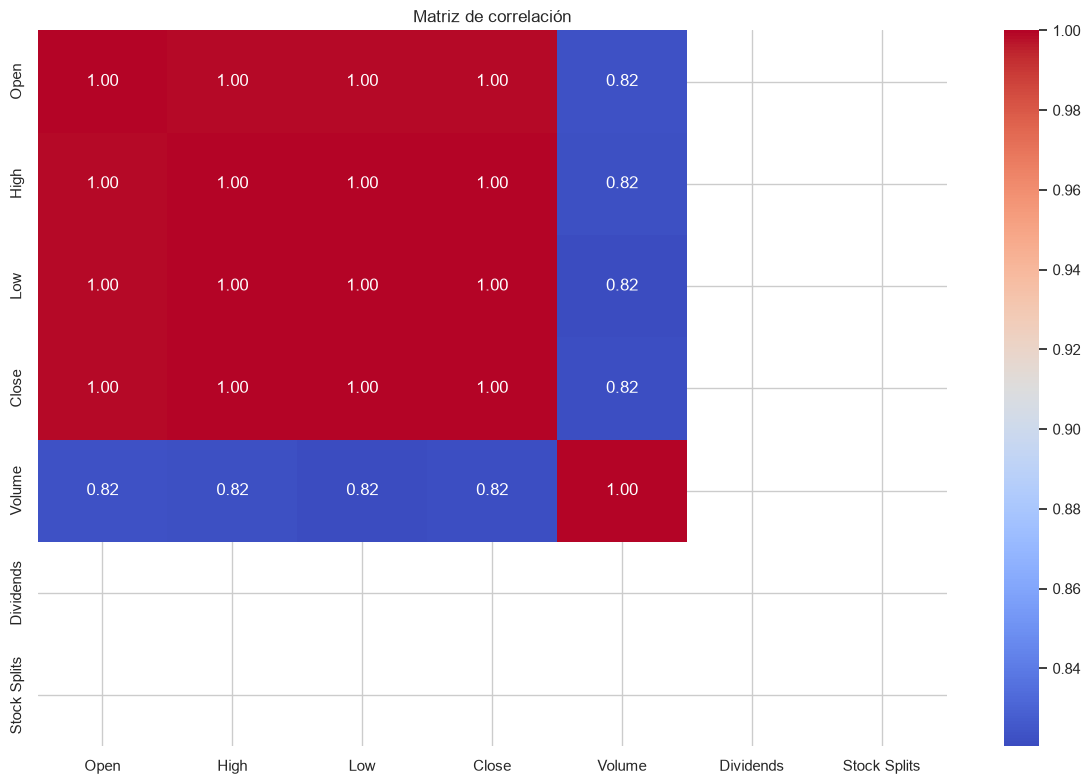

In [ ]:
# Crea un DataFrame solamente con valores numéricos
df_numerico = df.select_dtypes(include=np.number)

# Calcula la correlación entre las variables
matriz_correlacion = df_numerico.corr()

# Crea el espacio para el gráfico (12 x 8 pulgadas)
plt.figure(figsize=(12, 8))

# Genera el mapa de calor
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Agrega un título
plt.title("Matriz de correlación")

# Ajusta los elementos del gráfico
plt.tight_layout()

# Muestra el resultado
plt.show()